# Import the Libraries

In [6]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# Load the dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Data Understanding

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.shape

(5110, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

# Data Manipulation

In [39]:
# Replace the null values by mean beacause bmi is in normal distribution
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [40]:
df['bmi'].mean()

28.893236911794663

In [41]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [11]:
df.duplicated().sum()

0

<Axes: >

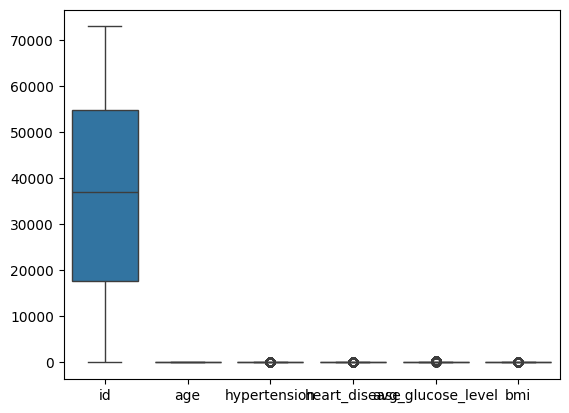

In [43]:
sns.boxplot(X)

In [44]:
# To fix the outliers we use IQR and Cappig Technique
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    X[col] = np.where(X[col]<lower_bound,lower_bound,
                      np.where(df[col]>upper_bound,upper_bound,X[col]))

<Axes: >

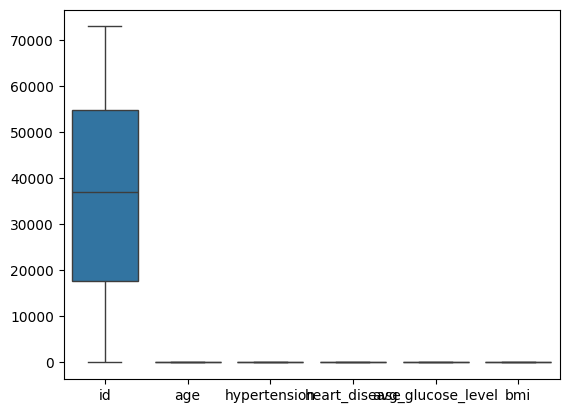

In [45]:
sns.boxplot(X)

In [ ]:
# Data is cleaned now we can perform data preprocessing and feature selection phase and seperate input and ouput features

In [111]:
y = df['stroke'] # Target variable
X = df.drop(columns=['id','stroke'],axis=1) # Input data

In [112]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [113]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4088, 10)
(4088,)
(1022, 10)
(1022,)


# Feature Scaling

In [114]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include='object').columns

In [115]:
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [116]:
ts = ColumnTransformer(transformers = [('t1',OrdinalEncoder(),cat_cols),
                                      ('t2',StandardScaler(),num_cols)])

In [117]:
X_train_trans = ts.fit_transform(X_train)
X_train_trans = pd.DataFrame(X_train_trans)

In [118]:
X_test_trans = ts.transform(X_test)
X_test_trans = pd.DataFrame(X_test_trans)

# KNN Classification

In [119]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

In [120]:
kn.fit(X_train_trans,y_train)

KNeighborsClassifier()

In [121]:
y_train_pred = kn.predict(X_train_trans)

In [122]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_train,y_train_pred)
print("Trainig score:",score)

Trainig score: 0.9540117416829745


In [123]:
y_pred = kn.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print("Testing score:",score)

Testing score: 0.9393346379647749


In [124]:
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       968
           1       0.00      0.00      0.00        54

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.90      0.94      0.92      1022



# Naive Bayes Classification

In [125]:
# Sinnce this is binary target data so we use the Guassian Naive Bayes theorem
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

In [126]:
gnb.fit(X_train_trans,y_train)

GaussianNB()

In [127]:
y_train_pred = gnb.predict(X_train_trans)
from sklearn.metrics import accuracy_score
score = accuracy_score(y_train,y_train_pred)
print("Training score:",score)

Training score: 0.8676614481409002


In [128]:
y_pred = gnb.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print("Testing score:",score)

Testing score: 0.8571428571428571


# Decision Tree Classification

In [129]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

In [130]:
dt.fit(X_train_trans,y_train)

DecisionTreeClassifier()

In [131]:
y_train_pred = dt.predict(X_train_trans)
from sklearn.metrics import accuracy_score
score = accuracy_score(y_train,y_train_pred)
print("Training score:",score)

Training score: 1.0


In [132]:
y_pred = dt.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print("Testing score:",score)

Testing score: 0.9090019569471625


# Logistic Regression - Classification

In [133]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [134]:
lr.fit(X_train_trans,y_train)

LogisticRegression()

In [135]:
y_train_pred = lr.predict(X_train_trans)
from sklearn.metrics import accuracy_score
score = accuracy_score(y_train,y_train_pred)
print("Training score:",score)

Training score: 0.9525440313111546


In [136]:
y_pred = lr.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print("Testing score:",score)

Testing score: 0.9471624266144814


# SVM

In [137]:
from sklearn.svm import SVC
sv = SVC()

In [138]:
sv.fit(X_train_trans,y_train)

SVC()

In [139]:
y_train_pred = sv.predict(X_train_trans)
from sklearn.metrics import accuracy_score
score = accuracy_score(y_train,y_train_pred)
print("Training score:",score)

Training score: 0.9522994129158513


In [140]:
y_pred = sv.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print("Testing score:",score)

Testing score: 0.9471624266144814


# Random Forest Classification

In [141]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train_trans,y_train)

RandomForestClassifier()

In [142]:
y_train_pred = rf.predict(X_train_trans)
from sklearn.metrics import accuracy_score
score = accuracy_score(y_train,y_train_pred)
print("Training score:",score)

Training score: 1.0


In [143]:
y_pred = rf.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print("Testing score:",score)

Testing score: 0.9461839530332681


# Ensemble Techniques

# Bagging Using Logistic Regression

In [144]:
LR = LogisticRegression(random_state=42)

In [145]:
from sklearn.ensemble import BaggingClassifier
model = BaggingClassifier(estimator=LR,n_estimators=20)
model.fit(X_train_trans,y_train)

BaggingClassifier(estimator=LogisticRegression(random_state=42),
                  n_estimators=20)

In [146]:
y_train_pred = model.predict(X_train_trans)
from sklearn.metrics import accuracy_score
score = accuracy_score(y_train,y_train_pred)
print("Training score:",score)

Training score: 0.9525440313111546


In [147]:
y_pred = model.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print("Testing score:",score)

Testing score: 0.9471624266144814


# Gradient Boosting

In [148]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Gradient Boosting classifier
gb_clf = GradientBoostingClassifier(
n_estimators=100,
learning_rate=0.1,
max_depth=3,
random_state=42
)

gb_clf.fit(X_train_trans, y_train)

# Predict and evaluate
y_pred = gb_clf.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print(score)

0.9442270058708415


# AdaBoosting Classifier

In [149]:

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')


# Base weak Learner (shallow tree)
base_estimator = DecisionTreeClassifier(max_depth=1)

# Adaboost Classifier
adb = AdaBoostClassifier(estimator=base_estimator,n_estimators=50,learning_rate=1.0,random_state=42)

adb.fit(X_train_trans,y_train)
y_pred = adb.predict(X_test_trans)
score = accuracy_score(y_test,y_pred)
print(score)

0.9452054794520548


In [150]:
import pickle


with open("model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("Model saved successfully as model.pkl")


Model saved successfully as model.pkl
